In [2]:
import model as m
from tensorflow.keras.models import load_model
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
import Evaluate_results as er
import matplotlib.pyplot as plt
import seaborn as sns
from keras import backend as K
import tensorflow as tf
import tensorflow as tf
import os
import json
from contextlib import redirect_stdout
import yaml
from matplotlib.colors import ListedColormap
from sklearn.manifold import TSNE
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout

2024-04-17 17:05:16.271899: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-04-17 17:05:16.293973: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-04-17 17:05:16.410556: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-04-17 17:05:16.410634: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-04-17 17:05:16.429687: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [3]:
dataset_path = 'Data/microarray_abundances_adjusted_combat.csv'
loss = "Poisson"
optimizer = "adam"
metrics = ["mae"]
epochs = 1500
batch_size = 512
validation_split = 0.2
lasso_alpha = 0.01
two_step_normalization = True


In [4]:
def create_new_folder(base_path="Results"):
    # Check if the Results directory exists, if not, create it
    results_dir = os.path.join(base_path, "Model_outputs")
    if not os.path.exists(results_dir):
        os.makedirs(results_dir)

    # Find existing result folders and determine the next number
    existing_folders = [name for name in os.listdir(results_dir) if os.path.isdir(os.path.join(results_dir, name)) and "result_standar_microarray" in name]
    if not existing_folders:
        next_number = 1
    else:
        # Sort existing folders to get the highest numbered folder
        existing_folders.sort()
        last_folder = existing_folders[-1]
        last_number = int(last_folder.replace("result_standar_microarray", ""))
        next_number = last_number + 1

    # Generate the name for the new folder
    new_folder_name = "result_standar_microarray{:02d}".format(next_number)
    new_folder_path = os.path.join(results_dir, new_folder_name)

    # Create the new folder
    os.makedirs(new_folder_path)

    return new_folder_path

In [5]:
def plot_distrobution_features(expression_df, age:list, n_features=None):
    def map_age(age):
        if age == 35:
            return 'Y'
        elif age > 65:
            return 'O'
        else:
            return 'M'
    x = expression_df
    if n_features:
        x=x.sample(n=n_features, axis='columns')
    x["Age"] = age.apply(lambda age: map_age(age))
    data = x
    melted_data = pd.melt(data,id_vars="Age",
                    var_name="features",
                    value_name='value')

    plt.figure(figsize=(10,10))
    sns.violinplot(x="features", y="value", hue="Age", data=melted_data,split=True, inner="quart")
    plt.xticks(rotation=90)


    #sns.boxplot(x="features", y="value", hue="Age", data=melted_data, showfliers=False)
    #plt.xticks(rotation=90)
    return melted_data


In [6]:
def map_to_category(age):
    if age < 35:
        return "Young"
    elif age > 65:
        return "Old"
    else:
        return "MiddleAge"

In [7]:
def color_feature_selction_TSNE(df):
    """
    make sure df has the expression and the column Age
    """
    feature_df = pd.DataFrame(df)
    feature_df_t = pd.DataFrame(df) 
    feature_df_t["Age"]=  [map_to_category(age) for age in df["Age"]] 
    tab20_colors = plt.cm.tab10.colors
    num_colors = len(np.unique(feature_df_t["Age"]))
    colors = [tab20_colors[i] for i in range(num_colors)]
    custom_cmap = ListedColormap(colors)
    ategory_map = {category: i for i, category in enumerate(feature_df_t["Age"])}
    category_map = {'Young': -1, 'MiddleAge': 0, 'Old': 1}
    numeric_age_order = [category_map[experiment] for experiment in feature_df_t["Age"]]
    X = feature_df.drop(columns=["Age"]).values 
    tSNE=TSNE(n_components=2)
    tSNE_result=tSNE.fit_transform(X)
    # Step 3: Visualize the clusters
    # Plot the first two principal components and color them according to the assigned clusters
    x=tSNE_result[:,0]
    y=tSNE_result[:,1]

    plt.figure(figsize=(8, 6))
    plt.scatter(x,y, c=numeric_age_order, cmap=custom_cmap, s=50, alpha=0.5)
    plt.title('TSNE Adjusted')
    #plt.colorbar(label="Experiment", spacing ="uniform",  values=numeric_experiment_order)

    # Create legend with experiment names
    legend_handles = [plt.Line2D([0], [0], marker='o',  markerfacecolor=color, markersize=10, label=f'Experiment {i+1}') for i, color in enumerate(colors)]
    plt.legend(handles=legend_handles, labels=list(category_map.keys()), loc='best')

    #plt.legend(list(category_map.keys()))
    #plt.show()

    plt.savefig(f"{m.output_directory}/TSNE_Scatter_Plot_feature_selection.jpg")

In [8]:
def save_performance_results(results, my_model):
    def analyze_restults(results, my_model):
        results["Experiment"] = my_model.z_test["Experiment"].values
        results["Sample"] = my_model.z_test["Sample"].values
        results["Sex"] = my_model.z_test["Sex"].values
        results["Status"] = my_model.z_test["Status"].values

        results["absolute_error"] = abs(results["Actual"]-results["Predicted"])
        results["big_absolute_error"] = np.where(results["absolute_error"] < 5, 0, results["absolute_error"])
        return results

    results = analyze_restults(results, my_model)
    with open(f"{m.output_directory}/model_summary.txt", "a") as f:
        # Redirect the stdout to the file
        with redirect_stdout(f):
            print("/n/t Actual age distribution:")
            print(results["Actual"].describe())
            print("/n/t Predicted age distribution:")
            print(results["Predicted"].describe())
            print("/n/t Predicted absolute error distribution:")
            print(results["absolute_error"].describe())
            print("/n/n/t /t Is the experiment acting the outcome?/n")
            
            print("/n/t Error distribution absolute_error ~ Experiment anova_lm:")
            print(er.evaluate_error_experiment(results))
            print("/n/t Krustal Wallis test:")
            print (er.evaluate_Kruskal_Wallis(results))
            print("/n/t Dunnes test:")
            print(er.evaluate_Dunnes_test(results))
    er.plot_Dunes_result(er.evaluate_Dunnes_test(results), save=True, file_name=f"{m.output_directory}/Dunnes_test.png")


In [9]:
def run_all():

    m.output_directory=create_new_folder()
    training_data=pd.read_csv(dataset_path)
    my_model = m.Model(training_data)
    normalized_X_train, normalized_X_test_fs = my_model.prepare_data(df=training_data, lasso_alpha=lasso_alpha, two_step=two_step_normalization)
    my_model.train(normalize_X_train=normalized_X_train, 
                    epochs=epochs, optimizer=optimizer,
                    loss=loss, metrics=metrics, batch_size=batch_size, validation_split=validation_split)
    m.plot_model(my_model.model, f'{m.output_directory}/model.png', show_shapes=True)
    results, error = my_model.test(normalized_X_test_fs, my_model.y_test)
    m.print_performance(my_model.history, results, my_model.z_test, save=True)

    conf_dic = {'dataset':dataset_path,
                'loss': loss,
                'optimizer': optimizer,
                'metrics': metrics,
                'epochs': epochs, 
                'batch_size': batch_size, 
                'validation_split': validation_split, 
                'lasso_alpha': lasso_alpha, 
                'two_step_normalization': two_step_normalization}
    with open(f"{m.output_directory}/model_summary.txt", "a") as f:
        # Redirect the stdout to the file
        with redirect_stdout(f):
            print("Error: ")
            print(error)

    save_performance_results(results, my_model)
    clean_df_z = pd.DataFrame(my_model.z_test.values)
    clean_df_z.columns = my_model.z_test.columns
    results_all_metadata = pd.concat([results,clean_df_z ], axis=1)
    with open(f"{m.output_directory}/configuration.yaml", "w") as yaml_file:
        yaml.dump(conf_dic, yaml_file, default_flow_style=False)
    with open(f"{m.output_directory}/model_architecture.yaml", "w") as yaml_file:
        yaml.dump(json.loads(my_model.model.to_json()), yaml_file, default_flow_style=False)
    with open(f"{m.output_directory}/selected_features.csv", "w") as f:
        f.write("\n".join(list(my_model.model_in_features)))

    feature_df = pd.DataFrame(normalized_X_train)
    feature_df = feature_df.dropna()
    feature_df
    feature_df["Age"]= my_model.y_train.values
    color_feature_selction_TSNE(feature_df)
    # Now check with the training data
        
        



In [56]:
dataset_path = 'Data/trainign_dataset_51270_microarray_adjusted.csv'
dataset_path = 'Data/microarray_clean_status.csv'
dataset_path = 'Data/microarray_abundances_adjusted_combat.csv'
dataset_path = "Results/augmented_data/microarray/SMOTE/All_samples_special_divition_after_batch_correction_combat.csv"
loss = "mse"
optimizer = "adamW"
metrics = ["mae"]
epochs = 1000
batch_size = 50
validation_split = 0.2
lasso_alpha = .7
two_step_normalization = False
    

In [11]:
#run_all()

In [12]:

def my_train_data(X_train, y_train, optimizer='adam', loss='mse', metrics=['mae'], epochs=1500, validation_split=0.1,
              batch_size=50):
    """
    Train the data
    
    :return: The trained model
    """

    n_features = X_train.shape[1]
    new_model = Sequential()

    # Add layers to the model 
    new_model.add(Dense(8, activation='relu', kernel_initializer='he_normal', input_shape=(n_features,)))
    new_model.add(Dense(16, activation='relu', kernel_initializer='he_normal', input_shape=(n_features,)))
    new_model.add(Dropout(0.5))  # Adding dropout to reduce overfitting
    new_model.add(Dense(32, activation='relu', kernel_initializer='he_normal'))
    new_model.add(Dropout(0.5))  # Adding dropout to reduce overfitting
    new_model.add(Dense(64, activation='softsign', kernel_initializer='he_normal'))
    new_model.add(Dense(32, activation='relu', kernel_initializer='he_normal'))
    new_model.add(Dropout(0.5))  # Adding dropout to reduce overfitting
    new_model.add(Dense(16, activation='relu', kernel_initializer='he_normal'))
    new_model.add(Dropout(0.5))
    new_model.add(Dense(8, activation='relu', kernel_initializer='he_normal', input_shape=(n_features,)))
    new_model.add(Dense(1))

    # Compile the model
    new_model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

    new_model_history = new_model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0, validation_split=validation_split)
    return new_model, new_model_history
m.train_data=my_train_data

In [57]:
m.output_directory=create_new_folder()
training_data=pd.read_csv(dataset_path)
my_model = m.Model(training_data)
normalized_X_train, normalized_X_test_fs = my_model.prepare_data(df=training_data, lasso_alpha=lasso_alpha, two_step=two_step_normalization)

In [13]:


my_model.train(normalize_X_train=normalized_X_train, 
                epochs=epochs, optimizer=optimizer,
                loss=loss, metrics=metrics, batch_size=batch_size, validation_split=validation_split)
m.plot_model(my_model.model, f'{m.output_directory}/model.png', show_shapes=True)
results, error = my_model.test(normalized_X_test_fs, my_model.y_test)
m.print_performance(my_model.history, results, my_model.z_test, save=True)

conf_dic = {'dataset':dataset_path,
            'loss': loss,
            'optimizer': optimizer,
            'metrics': metrics,
            'epochs': epochs, 
            'batch_size': batch_size, 
            'validation_split': validation_split, 
            'lasso_alpha': lasso_alpha, 
            'two_step_normalization': two_step_normalization}
with open(f"{m.output_directory}/model_summary.txt", "a") as f:
    # Redirect the stdout to the file
    with redirect_stdout(f):
        print("Error: ")
        print(error)

save_performance_results(results, my_model)
clean_df_z = pd.DataFrame(my_model.z_test.values)
clean_df_z.columns = my_model.z_test.columns
results_all_metadata = pd.concat([results,clean_df_z ], axis=1)
results_all_metadata.to_csv(f"{m.output_directory}/results_all_metadata.csv")
with open(f"{m.output_directory}/configuration.yaml", "w") as yaml_file:
    yaml.dump(conf_dic, yaml_file, default_flow_style=False)
with open(f"{m.output_directory}/model_architecture.yaml", "w") as yaml_file:
    yaml.dump(json.loads(my_model.model.to_json()), yaml_file, default_flow_style=False)
with open(f"{m.output_directory}/selected_features.csv", "w") as f:
    f.write("\n".join(list(my_model.model_in_features)))

feature_df = pd.DataFrame(normalized_X_train)
feature_df = feature_df.dropna()
feature_df
feature_df["Age"]= my_model.y_train.values
color_feature_selction_TSNE(feature_df)

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:85: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


KeyboardInterrupt: 

Running the Violins of the features already selected

,Age,features,value
0,M,AI797017,-0.019101
1,M,AI797017,2.300133
2,M,AI797017,0.069315
3,M,AI797017,0.350089
4,O,AI797017,-0.004821
...,...,...,...
9310,M,U30329,-0.130099
9311,O,U30329,0.459499
9312,M,U30329,-0.342713
9313,M,U30329,0.018927


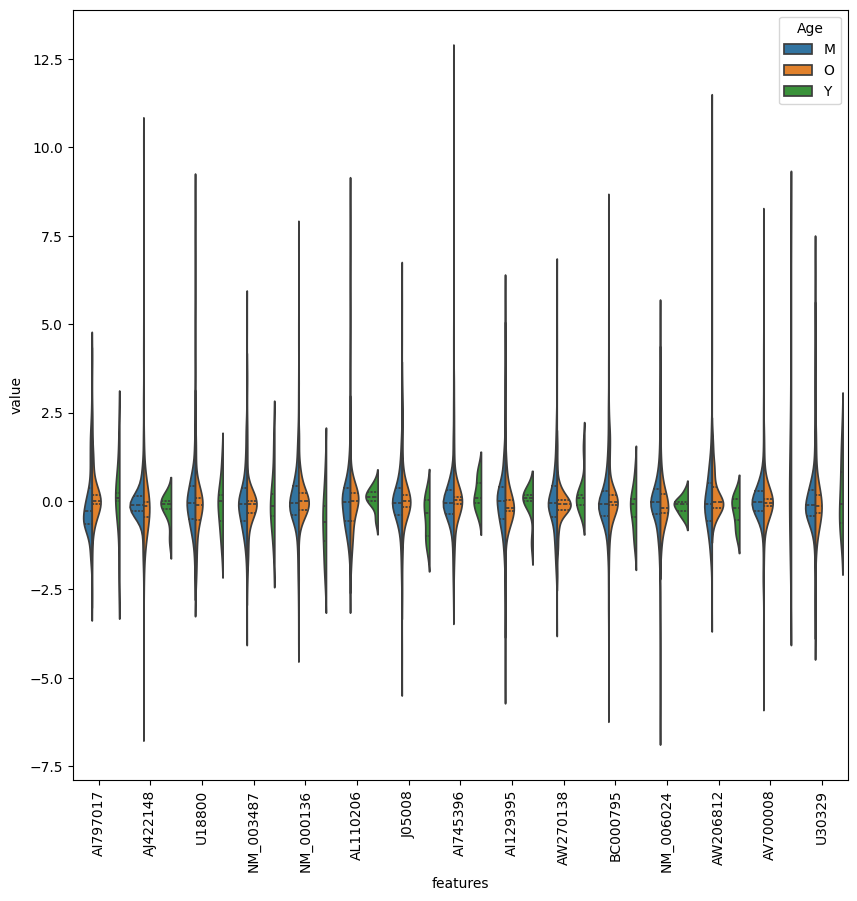

In [13]:
feature_df= pd.DataFrame(normalized_X_train, columns=my_model.model_in_features)
age_df = pd.Series( my_model.y_train.values)
md = plot_distrobution_features(expression_df=feature_df, age=age_df, n_features=15)
md

In [14]:
my_model.y_train


46     54.37
410    46.00
363    42.00
88     44.83
760    71.20
       ...  
627    28.00
701    76.09
553    41.00
598    53.00
137    52.49
Name: Age, Length: 621, dtype: float64

Running the violins on random features

In [ ]:
feature_df = pd.DataFrame(my_model.X_train)
age_df = pd.Series( my_model.y_train.values)
md= plot_distrobution_features(expression_df=feature_df, age=age_df, n_features=15)
md

In [ ]:
type(my_model.y_train)


In [ ]:
feature_df= pd.DataFrame(normalized_X_train, columns=my_model.model_in_features)
age_df = pd.Series( my_model.y_train.values)
md = plot_distrobution_features(expression_df=feature_df, age=age_df, n_features=5)
md

In [ ]:
feature_df = pd.DataFrame(my_model.X_train)
age_df = pd.Series( my_model.y_train.values)
md= plot_distrobution_features(expression_df=feature_df, age=age_df, n_features=5)
md

Lets try with clusters; TSNE

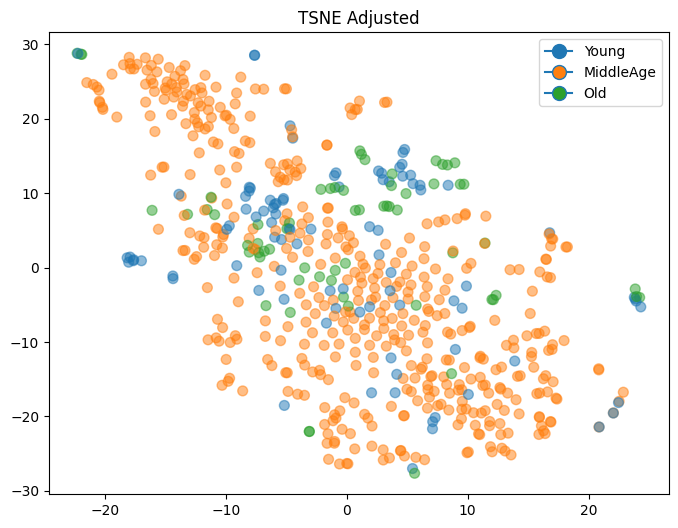

In [15]:
feature_df = pd.DataFrame(my_model.X_train)
feature_df["Age"]= my_model.y_train.values
color_feature_selction_TSNE(feature_df)

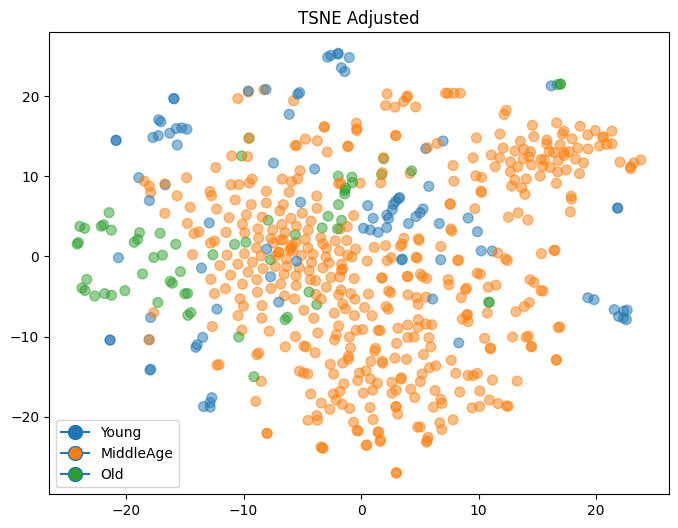

In [16]:


feature_df = pd.DataFrame(normalized_X_train)
feature_df = feature_df.dropna()
feature_df
feature_df["Age"]= my_model.y_train.values
color_feature_selction_TSNE(feature_df)

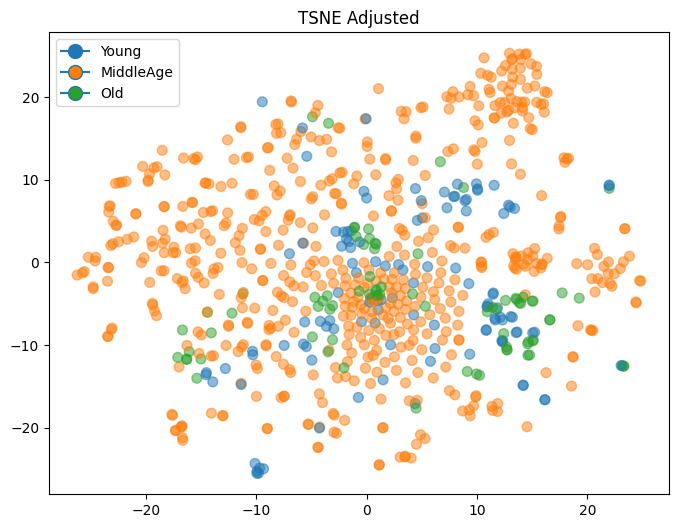

In [18]:
feature_df = pd.DataFrame(training_data)
feature_df = feature_df.drop(columns=['Experiment', 'Sample'])
color_feature_selction_TSNE(feature_df)

In [ ]:
training_data.columns

In [ ]:
len(training_data[(training_data["Sex"]=="Male")])

Using random forest instead

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

def my_evaluate_model(model, X_test, y_test):
    """
    Evaluate the model
    
    :param model: The trained model to evaluate
    :param X_test: The test data
    :param y_test: The test labels
    """
    # Make predictions using the trained model
    predictions = model.predict(X_test)

    # Calculate mean absolute error (MAE)
    mae = mean_absolute_error(y_test, predictions)
    print('MAE: %.3f' % mae)

    # Create a DataFrame to display actual vs predicted values
    results = pd.DataFrame({'Actual': y_test, 'Predicted': predictions})

    return results
m.evaluate_model=my_evaluate_model

In [ ]:

def my_train_data(X_train, y_train, n_estimators=500, max_depth=None, min_samples_split=10, min_samples_leaf=20,
                  bootstrap=True):
    """
    Train the data using Random Forest Regressor
    
    :return: The trained model
    """

    # Initialize Random Forest Regressor
    rf_model = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth,
                                      min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf,
                                      bootstrap=bootstrap)

    # Fit the model
    rf_model.fit(X_train, y_train)

    return rf_model



In [ ]:
m.train_data=my_train_data
m.output_directory=create_new_folder()
training_data=pd.read_csv(dataset_path)
my_model = m.Model(training_data)
normalized_X_train, normalized_X_test_fs = my_model.prepare_data(df=training_data, lasso_alpha=lasso_alpha, two_step=two_step_normalization)

my_model.model = m.train_data(X_train=normalized_X_train, y_train=my_model.y_train, n_estimators=400, max_depth=None, min_samples_split=20, min_samples_leaf=20,
                  bootstrap=True)

results = m.evaluate_model(my_model.model, normalized_X_test_fs, my_model.y_test)

m.plot_results(results, my_model.z_test, save=True)

conf_dic = {'dataset':dataset_path,
            'loss': loss,
            'optimizer': optimizer,
            'metrics': metrics,
            'epochs': epochs, 
            'batch_size': batch_size, 
            'validation_split': validation_split, 
            'lasso_alpha': lasso_alpha, 
            'two_step_normalization': two_step_normalization}


save_performance_results(results, my_model)
clean_df_z = pd.DataFrame(my_model.z_test.values)
clean_df_z.columns = my_model.z_test.columns
results_all_metadata = pd.concat([results,clean_df_z ], axis=1)
results_all_metadata.to_csv(f"{m.output_directory}/results_all_metadata.csv")
with open(f"{m.output_directory}/configuration.yaml", "w") as yaml_file:
    yaml.dump(conf_dic, yaml_file, default_flow_style=False)
with open(f"{m.output_directory}/model_architecture.yaml", "w") as yaml_file:
    for param_name, param_value in my_model.model.get_params().items():
            yaml_file.write(f"{param_name}: {param_value}\n")
with open(f"{m.output_directory}/selected_features.csv", "w") as f:
    f.write("\n".join(list(my_model.model_in_features)))

feature_df = pd.DataFrame(normalized_X_train)
feature_df = feature_df.dropna()
feature_df
feature_df["Age"]= my_model.y_train.values
color_feature_selction_TSNE(feature_df)


In [ ]:
lasso_alpha = 0.9
m.train_data=my_train_data
m.output_directory=create_new_folder()
training_data=pd.read_csv(dataset_path)
my_model = m.Model(training_data)
normalized_X_train, normalized_X_test_fs = my_model.prepare_data(df=training_data, lasso_alpha=lasso_alpha, two_step=two_step_normalization)


feature_df = pd.DataFrame(normalized_X_train)
feature_df = feature_df.dropna()
feature_df
feature_df["Age"]= my_model.y_train.values
color_feature_selction_TSNE(feature_df)


In [ ]:


lasso_alpha

In [ ]:

results

In [ ]:
#m.print_performance(my_model.history, results, my_model.z_test, save=True)


## Using catboost insted

In [58]:


from catboost import CatBoostRegressor
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

X_train = normalized_X_train
X_test = normalized_X_test_fs
y_train = my_model.y_train
y_test = my_model.y_test




# Initialize CatBoostClassifier
regressor = CatBoostRegressor(iterations=100,  # Number of boosting iterations
                              learning_rate=0.1,  # Learning rate
                              depth=6,  # Depth of trees
                              random_state=42,  # Random seed for reproducibility
                              verbose=0)  # Verbosity level (0 - silent, 1 - verbose)

# Fit the model
regressor.fit(X_train, y_train)

# Make predictions
y_pred = regressor.predict(X_test)

# Evaluate mean squared error
mse = mean_squared_error(y_test, y_pred)


In [59]:
result_cat_df = pd.DataFrame({'Actual': y_test.tolist(), 'Predicted': y_pred})
result_cat_df

,Actual,Predicted
0,74.5,43.574038
1,40.0,51.801259
2,51.0,56.321951
3,51.0,51.978267
4,55.5,50.192082
...,...,...
161,51.0,49.272743
162,40.0,45.463156
163,26.5,30.038241
164,51.0,51.842779


In [61]:
my_model.z_test

,Age
285,74.5
251,40.0
112,51.0
1,51.0
189,55.5
...,...
223,51.0
395,40.0
780,26.5
321,51.0


In [ ]:
m.plot_results(result_cat_df, my_model.z_test, save=True, print_label='Experiment')

/tmp/ipykernel_210504/1394342877.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='Actual', y='Predicted', data=result_cat_df, palette='Set1', alpha=0.8, edgecolor='w')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


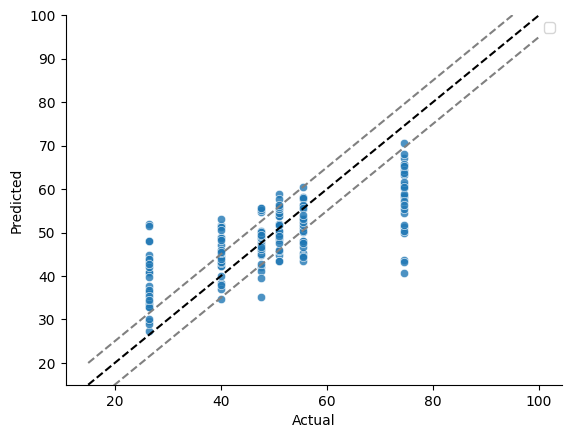

In [62]:
# Your existing scatter plot code
sns.scatterplot(x='Actual', y='Predicted', data=result_cat_df, palette='Set1', alpha=0.8, edgecolor='w')

# Plotting the diagonal line
plt.plot([15, 100], [15, 100], color='black', linestyle='--')

# Plotting lines parallel to the diagonal line
plt.plot([15, 100], [20, 105], color='gray', linestyle='--')
plt.plot([15, 100], [10, 95], color='gray', linestyle='--')

# Customizing the plot
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.gca().set_ylim(bottom=15, top=100)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

In [17]:
def map_to_category(age):
    if age <= 35:
        return "Young"
    elif age > 65:
        return "Old"
    else:
        return "MiddleAge"

In [63]:
result_cat_df

,Actual,Predicted
0,74.5,43.574038
1,40.0,51.801259
2,51.0,56.321951
3,51.0,51.978267
4,55.5,50.192082
...,...,...
161,51.0,49.272743
162,40.0,45.463156
163,26.5,30.038241
164,51.0,51.842779


In [64]:
age_ranges = [
 {'label': '1 Young 1', 'range': (18, 25), 'count': 85},
 {'label': '2 Young 2', 'range': (25, 35), 'count': 97},
 {'label': '3 Middle Age 1', 'range': (35, 45), 'count': 79},
 {'label': '4 Middle Age 2', 'range': (45, 55), 'count': 85},
 {'label': '5 Middle Age 3', 'range': (55, 65), 'count': 85},
 {'label': '6 Old 1', 'range': (65, 75), 'count': 87},
 {'label': '7 Old 2', 'range': (75, 85), 'count': 87},
 {'label': '8 Old 3', 'range': (85, 100), 'count': 87}]
def assign_age_group(age, age_groups):
    for group in age_groups:
        if group['range'][0] <= age < group['range'][1]:
            return group['label']
    return 'Unknown'
actual_categories = ["1 Young 1", "2 Young 2", "3 Middle Age 1", "4 Middle Age 2", "5 Middle Age 3", "6 Old 1", "7 Old 2", "8 Old 3"]
actual_categories.sort()

In [65]:

a= result_cat_df["Actual"].apply(lambda x: assign_age_group(x, age_ranges))
#a = a.map(category_map)
b= result_cat_df["Predicted"].apply(lambda x: assign_age_group(x, age_ranges))
#b = b.map(category_map)
result_cat_df_cate = result_cat_df.copy()
result_cat_df_cate["Actual"] = a
result_cat_df_cate["Predicted"] = b


In [66]:
result_cat_df_cate

,Actual,Predicted
0,6 Old 1,3 Middle Age 1
1,3 Middle Age 1,4 Middle Age 2
2,4 Middle Age 2,5 Middle Age 3
3,4 Middle Age 2,4 Middle Age 2
4,5 Middle Age 3,4 Middle Age 2
...,...,...
161,4 Middle Age 2,4 Middle Age 2
162,3 Middle Age 1,4 Middle Age 2
163,2 Young 2,2 Young 2
164,4 Middle Age 2,4 Middle Age 2


In [70]:
result_cat_df_cate['Predicted'].value_counts()

Predicted
4 Middle Age 2    71
3 Middle Age 1    41
5 Middle Age 3    37
2 Young 2         11
6 Old 1            6
Name: count, dtype: int64

In [69]:
result_cat_df_cate['Actual'].value_counts()

Actual
4 Middle Age 2    53
5 Middle Age 3    32
2 Young 2         28
6 Old 1           27
3 Middle Age 1    26
Name: count, dtype: int64

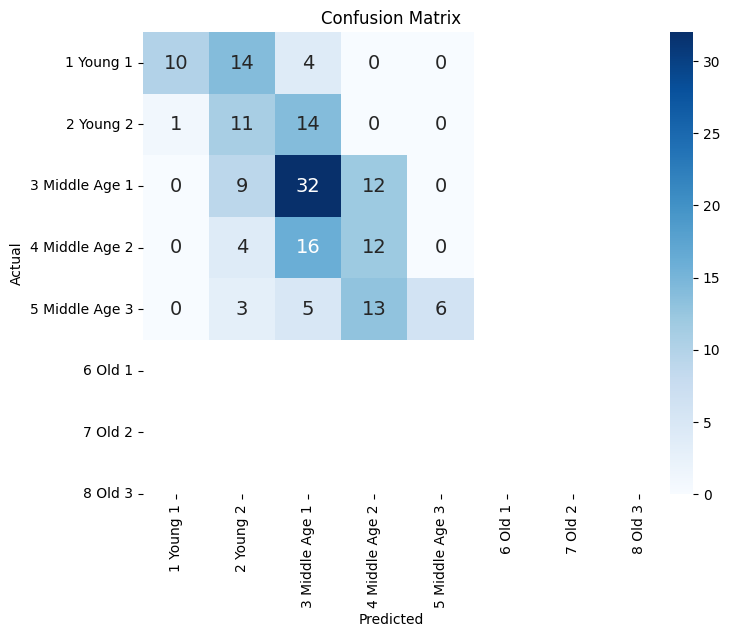

In [67]:
conf_matrix = confusion_matrix(result_cat_df_cate['Actual'], result_cat_df_cate['Predicted'])

# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 14},
            xticklabels=actual_categories, yticklabels=actual_categories)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [40]:
result_cat_df_cate[(result_cat_df_cate['Actual']=="Middle Age 2")&(result_cat_df_cate['Predicted']=="Middle Age 1")]

,Actual,Predicted,Experiment
14,Middle Age 2,Middle Age 1,GSE48278
40,Middle Age 2,Middle Age 1,GSE13070
50,Middle Age 2,Middle Age 1,GSE13070
51,Middle Age 2,Middle Age 1,GSE13070
75,Middle Age 2,Middle Age 1,GSE87105
96,Middle Age 2,Middle Age 1,GSE13070
153,Middle Age 2,Middle Age 1,GSE13070


In [68]:
for age in actual_categories:
    print(age)
    print(len(result_cat_df_cate[(result_cat_df_cate['Actual']==age)&(result_cat_df_cate['Predicted']==age)]))

1 Young 1
0
2 Young 2
10
3 Middle Age 1
11
4 Middle Age 2
32
5 Middle Age 3
12
6 Old 1
6
7 Old 2
0
8 Old 3
0
